# Machine Learning models applied.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  
import seaborn as sns
import warnings

from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OneHotEncoder, PowerTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn import neighbors
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, r2_score, explained_variance_score

import scipy.stats as stats
from scipy.stats import kurtosis, boxcox

import mglearn
import matplotlib

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('C:/Users/elias/OneDrive/Desktop/MachineLearning/MLProject/Copia de DataBaseSGC.csv', delimiter=';', low_memory=False)
"""df = df.sort_values(by="T_0.01_RotD50", ascending=True)
df.reset_index(drop=True, inplace=True)"""
#df= pd.read_excel('C:/Users/elias/OneDrive/Desktop/MachineLearning/MLProject/CopiaDataBaseSGC.xlsx')

'df = df.sort_values(by="T_0.01_RotD50", ascending=True)\ndf.reset_index(drop=True, inplace=True)'

In [3]:
df

,Record Sequence Number,EQID,Epicenter Latitude (deg; positive N),Epicenter Longitude (deg; positive E),Hypocenter Depth (km),Magnitude,Magnitude type,Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust),Nodal Plane 1 Strike (deg),Nodal Plane 1 Dip (deg),...,Station Elevation (m),Tmax,Valor_T1.5,Repi_OpenQuake,Rjb_OpenQuake,Rrup_OpenQuake,Rx_OpenQuake,Rhypo_OpenQuake,Ry0_OpenQuake,T_0.01_RotD50
0,1,EC_20160416235837,0.35,-79.93,21.0,7.7822,Mw,Interface,27,21,...,2664.0,5,0.12,193.902831,154.345123,160.846919,212.387613,197.997332,28.416246,27.209753
1,2,EC_20160518075703,0.43,-79.79,16.0,6.7001,Mw,Interface,28,18,...,2664.0,2,0.14,218.211371,204.079653,205.275676,204.424794,219.418467,85.273825,4.097850
2,3,EC_20160518164644,0.50,-79.62,30.0,6.8684,Mw,Interface,28,21,...,2664.0,5,0.12,213.354397,194.839359,198.622587,191.386016,216.833228,96.972004,6.819786
3,4,EC_20160416235837,0.35,-79.93,21.0,7.7822,Mw,Interface,27,21,...,13.0,2,0.25,386.687925,319.308209,321.266537,185.456450,388.493021,293.872683,22.289756
4,5,EC_20160518075703,0.43,-79.79,16.0,6.7001,Mw,Interface,28,18,...,13.0,7,0.32,407.841031,387.233044,387.195348,182.156285,408.347566,351.161989,1.875562
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8806,8807,CO_20191227032038,3.41,-74.17,16.0,4.4000,Mw,Crustal,142,83,...,696.0,16,0.15,296.999096,296.065638,296.180748,-31.733134,297.506537,294.384639,0.685194
8807,8808,CO_20200114175709,6.82,-73.15,150.0,4.6000,Mw,Deep,11,90,...,696.0,16,0.07,179.677526,178.188108,231.767387,113.834068,235.373785,137.078999,0.395032
8808,8809,CO_20200117043206,2.12,-79.56,20.0,4.7000,Mw,Interface,44,25,...,696.0,40,0.02,876.174697,873.178545,872.100140,-344.376016,876.453666,802.354454,0.007543
8809,8810,CO_20200120180005,7.27,-78.64,4.0,5.1000,Mw,Crustal,282,68,...,696.0,40,0.02,722.499160,719.534386,719.316553,-55.220635,722.527004,717.775640,0.046228


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Record Sequence Number,8811.0,4406.000000,2543.660944,1.000000,2203.500000,4406.000000,6608.500000,8811.000000
Epicenter Latitude (deg; positive N),8811.0,5.896834,3.759842,-4.825000,3.440000,6.535500,7.280000,13.260000
Epicenter Longitude (deg; positive E),8811.0,-76.241968,2.851960,-81.260000,-78.290000,-76.040000,-73.280000,-67.973000
Hypocenter Depth (km),8811.0,59.993065,62.345192,1.000000,10.000000,19.600000,132.000000,209.900000
Magnitude,8811.0,4.988405,0.675945,3.800000,4.500000,4.900000,5.260000,7.782200
Nodal Plane 1 Strike (deg),8811.0,177.660651,106.265249,2.000000,88.000000,168.000000,265.000000,360.000000
Nodal Plane 1 Dip (deg),8811.0,58.328567,23.395038,1.000000,41.000000,65.000000,80.000000,90.000000
Nodal Plane 1 Rake Angle (deg),8811.0,13.555783,109.983810,-180.000000,-69.000000,20.000000,107.000000,180.000000
Nodal Plane 2 Strike (deg),8811.0,169.453978,108.282067,0.000000,71.000000,172.000000,258.000000,360.000000
Nodal Plane 2 Dip (deg),8811.0,68.298604,16.069385,14.000000,58.000000,69.000000,82.000000,90.000000


In [5]:
#df = df.iloc[:, :df.columns.get_loc("T_0.01_RotD50") + 1]

In [6]:
categorical_columns = df.select_dtypes(include=['object']).columns
categorical_columns

Index(['EQID', 'Magnitude type',
       'Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)',
       'Style-of-Faulting (S; R; N; U)', 'Station ID', 'Station Code'],
      dtype='object')

In [7]:
df.drop(["Record Sequence Number"], axis=1, inplace=True)
df.drop(["Station ID"], axis=1, inplace=True)
df.drop(["Station Code"], axis=1, inplace=True)
df.drop(["Magnitude type"], axis=1, inplace=True)
df.drop(["EQID"], axis=1, inplace=True)
df.drop(["Valor_T1.5"], axis=1, inplace=True)
df.drop(["Tmax"], axis=1, inplace=True)
df.drop(["Epicenter Latitude (deg; positive N)"], axis=1, inplace=True)
df.drop(["Epicenter Longitude (deg; positive E)"], axis=1, inplace=True)
df.drop(["Station Latitude (deg positive N)"], axis=1, inplace=True)
df.drop(["Station Longitude (deg positive E)"], axis=1, inplace=True)
"""df.drop(["Topografia"], axis=1, inplace=True)
df.drop(["Geologia"], axis=1, inplace=True)"""

'df.drop(["Topografia"], axis=1, inplace=True)\ndf.drop(["Geologia"], axis=1, inplace=True)'

In [8]:
categorical_columns = df.select_dtypes(include=['object']).columns
categorical_columns

Index(['Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)', 'Style-of-Faulting (S; R; N; U)'], dtype='object')

In [9]:
df = df[df['T_0.01_RotD50'] > 0]
"""df = df[df['Rhypo_OpenQuake'] < 600]
df["T_0.01_RotD50"]= df["T_0.01_RotD50"]/980
df = df[df['T_0.01_RotD50'] > 0.0001]
df["T_0.01_RotD50"]= df["T_0.01_RotD50"]*980
df.reset_index(drop=True, inplace=True)"""

'df = df[df[\'Rhypo_OpenQuake\'] < 600]\ndf["T_0.01_RotD50"]= df["T_0.01_RotD50"]/980\ndf = df[df[\'T_0.01_RotD50\'] > 0.0001]\ndf["T_0.01_RotD50"]= df["T_0.01_RotD50"]*980\ndf.reset_index(drop=True, inplace=True)'

In [10]:
df_copy = df.copy()

In [11]:
X= df_copy.copy()

In [12]:
df_copy["T_0.01_RotD50"]= np.log(df_copy["T_0.01_RotD50"])

In [13]:
df_copy.describe().T

,count,mean,std,min,25%,50%,75%,max
Hypocenter Depth (km),8809.0,60.004416,62.347718,1.000000,10.000000,20.000000,132.000000,209.900000
Magnitude,8809.0,4.988410,0.676019,3.800000,4.500000,4.900000,5.260000,7.782200
Nodal Plane 1 Strike (deg),8809.0,177.646838,106.261691,2.000000,88.000000,168.000000,265.000000,360.000000
Nodal Plane 1 Dip (deg),8809.0,58.327165,23.395052,1.000000,41.000000,65.000000,80.000000,90.000000
Nodal Plane 1 Rake Angle (deg),8809.0,13.527075,109.978298,-180.000000,-69.000000,20.000000,107.000000,180.000000
Nodal Plane 2 Strike (deg),8809.0,169.450335,108.280821,0.000000,71.000000,172.000000,258.000000,360.000000
Nodal Plane 2 Dip (deg),8809.0,68.298558,16.068522,14.000000,58.000000,69.000000,82.000000,90.000000
Nodal Plane 2 Rake Angle (deg),8809.0,18.633897,102.792576,-180.000000,-50.000000,18.000000,100.000000,177.000000
Fault Plane (1; 2; X),8809.0,1.440005,0.496416,1.000000,1.000000,1.000000,2.000000,2.000000
Station Elevation (m),8809.0,1192.927767,1107.990874,4.000000,234.000000,780.000000,1948.000000,4136.000000


In [14]:
Y=X[["T_0.01_RotD50"]].copy()
X.drop(["T_0.01_RotD50"],axis=1, inplace=True)


In [15]:
df_numerico = df_copy.select_dtypes(include=[float, int])


In [16]:
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Estandarizar datos
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
df_numerico.drop(["Fault Plane (1; 2; X)"], axis=1, inplace=True) #Se va a codificar dsp.
# Escalar las variables predictoras
df_scaled = pd.DataFrame(scaler_X.fit_transform(df_numerico.drop("T_0.01_RotD50", axis=1)), 
                         columns=df_numerico.drop("T_0.01_RotD50", axis=1).columns)
# Escalar la variable de respuesta
Aceleracion_escalada = scaler_y.fit_transform(df_numerico[["T_0.01_RotD50"]])  # Debe ser 2D
df_scaled["T_0.01_RotD50"] = Aceleracion_escalada.flatten()

In [17]:
df_scaled

,Hypocenter Depth (km),Magnitude,Nodal Plane 1 Strike (deg),Nodal Plane 1 Dip (deg),Nodal Plane 1 Rake Angle (deg),Nodal Plane 2 Strike (deg),Nodal Plane 2 Dip (deg),Nodal Plane 2 Rake Angle (deg),Station Elevation (m),Repi_OpenQuake,Rjb_OpenQuake,Rrup_OpenQuake,Rx_OpenQuake,Rhypo_OpenQuake,Ry0_OpenQuake,T_0.01_RotD50
0,0.095740,1.000000,0.069832,0.224719,0.844444,0.475000,0.776316,0.722689,0.643756,0.105786,0.085457,0.082760,0.554825,0.101188,0.016449,0.818684
1,0.071805,0.728266,0.072626,0.191011,0.841667,0.483333,0.802632,0.728291,0.643756,0.119195,0.112994,0.107552,0.552428,0.113096,0.049363,0.719777
2,0.138822,0.770529,0.072626,0.224719,0.841667,0.483333,0.776316,0.722689,0.643756,0.116516,0.107878,0.103840,0.548503,0.111659,0.056134,0.746389
3,0.095740,1.000000,0.069832,0.224719,0.844444,0.475000,0.776316,0.722689,0.002178,0.212135,0.176793,0.172278,0.546718,0.207081,0.170115,0.808264
4,0.071805,0.728266,0.072626,0.191011,0.841667,0.483333,0.802632,0.728291,0.002178,0.223804,0.214401,0.209067,0.545724,0.218117,0.203278,0.678944
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8804,0.071805,0.150670,0.391061,0.921348,0.588889,0.133333,0.578947,0.985994,0.167473,0.162659,0.163924,0.158279,0.481339,0.156503,0.170411,0.626334
8805,0.713260,0.200894,0.025140,1.000000,0.416667,0.280556,0.605263,0.000000,0.167473,0.097938,0.098658,0.122335,0.525158,0.121965,0.079351,0.597561
8806,0.090953,0.226006,0.117318,0.269663,0.255556,0.616667,0.671053,0.249300,0.167473,0.482159,0.483458,0.479653,0.387227,0.478326,0.464461,0.390752
8807,0.014361,0.326453,0.782123,0.752809,0.558333,0.511111,0.750000,0.943978,0.167473,0.397385,0.398389,0.394397,0.474269,0.392762,0.415500,0.485474


In [18]:
df_scaled.drop(["Nodal Plane 1 Rake Angle (deg)"], axis=1, inplace=True)
df_scaled.drop(["Nodal Plane 2 Rake Angle (deg)"], axis=1, inplace=True)
df_scaled.drop(["Nodal Plane 2 Dip (deg)"], axis=1, inplace=True)
df_scaled.drop(["Nodal Plane 2 Strike (deg)"], axis=1, inplace=True)
df_scaled.drop(["Rx_OpenQuake"], axis=1, inplace=True)
df_scaled.drop(["Ry0_OpenQuake"], axis=1, inplace=True)
df_scaled.drop(["Rhypo_OpenQuake"], axis=1, inplace=True)
df_scaled.drop(["Rrup_OpenQuake"], axis=1, inplace=True)
df_scaled.drop(["Repi_OpenQuake"], axis=1, inplace=True)

In [19]:
# Codificar la variable categórica con OneHotEncoder
X_categorical = df_copy[['Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)']].astype(str)

enc = OneHotEncoder(sparse_output=False)
X_encoded = enc.fit_transform(X_categorical)  # Devuelve un array listo para KNN

Y_categorical = df_copy[["Fault Plane (1; 2; X)"]].astype(str)

enc = OneHotEncoder(sparse_output=False)
Y_encoded = enc.fit_transform(Y_categorical)  

Z_categorical = df_copy[["Style-of-Faulting (S; R; N; U)"]].astype(str)

enc = OneHotEncoder(sparse_output=False)
Z_encoded = enc.fit_transform(Z_categorical)  

"""A_categorical = df_copy[['Topografia']].astype(str)

enc = OneHotEncoder(sparse_output=False)
A_encoded = enc.fit_transform(A_categorical)  

B_categorical = df_copy[['Geologia']].astype(str)

enc = OneHotEncoder(sparse_output=False)
B_encoded = enc.fit_transform(B_categorical) """

X_numerical = df_scaled.drop(columns=["T_0.01_RotD50"]).values

# Paso 3: Combinar características numéricas y codificadas
X_final = np.hstack((X_numerical, X_encoded,Y_encoded,Z_encoded#, A_encoded, B_encoded
                     ))

y = df_scaled["T_0.01_RotD50"].values  


In [20]:
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.3, random_state=0)

In [21]:
df_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
Hypocenter Depth (km),8809.0,0.282453,0.298457,0.0,0.043083,0.090953,0.627094,1.0
Magnitude,8809.0,0.298430,0.169760,0.0,0.175782,0.276229,0.366632,1.0
Nodal Plane 1 Strike (deg),8809.0,0.490634,0.296820,0.0,0.240223,0.463687,0.734637,1.0
Nodal Plane 1 Dip (deg),8809.0,0.644125,0.262866,0.0,0.449438,0.719101,0.887640,1.0
Station Elevation (m),8809.0,0.287737,0.268149,0.0,0.055663,0.187803,0.470474,1.0
Rjb_OpenQuake,8809.0,0.285114,0.198489,0.0,0.133736,0.239893,0.396430,1.0
T_0.01_RotD50,8809.0,0.558826,0.121876,0.0,0.463656,0.546515,0.646467,1.0


## KNN Neighbors


In [22]:
rmsle_val = []
best_rmsle = 1.0

for k in range(20):
    k = k+1
    knn = neighbors.KNeighborsRegressor(n_neighbors = k)
    knn.fit(X_train, y_train) 
    y_pred = knn.predict(X_test)
    rmsle = np.sqrt(mean_squared_log_error(y_test,y_pred))
    if (rmsle < best_rmsle):
        best_rmsle = rmsle
        best_k = k
    rmsle_val.append(rmsle)
    print('RMSLE value for k= ' , k , 'is:', rmsle)

print(f"Best RMSLE: {best_rmsle}, Best k: {best_k}")

RMSLE value for k=  1 is: 0.06013146975086404
RMSLE value for k=  2 is: 0.052261705247718955
RMSLE value for k=  3 is: 0.050289609485306606
RMSLE value for k=  4 is: 0.04958722599518054
RMSLE value for k=  5 is: 0.04956658887628312
RMSLE value for k=  6 is: 0.04967124120037776
RMSLE value for k=  7 is: 0.04958564225399503
RMSLE value for k=  8 is: 0.04963833664922237
RMSLE value for k=  9 is: 0.04971596293040859
RMSLE value for k=  10 is: 0.049906356340205626
RMSLE value for k=  11 is: 0.050098631973642026
RMSLE value for k=  12 is: 0.050297353345717104
RMSLE value for k=  13 is: 0.0505403918563058
RMSLE value for k=  14 is: 0.050764870224406976
RMSLE value for k=  15 is: 0.05101014113963337
RMSLE value for k=  16 is: 0.05125829684298001
RMSLE value for k=  17 is: 0.051564795771313926
RMSLE value for k=  18 is: 0.05175697246266337
RMSLE value for k=  19 is: 0.05192737364109727
RMSLE value for k=  20 is: 0.052063189069196034
Best RMSLE: 0.04956658887628312, Best k: 5


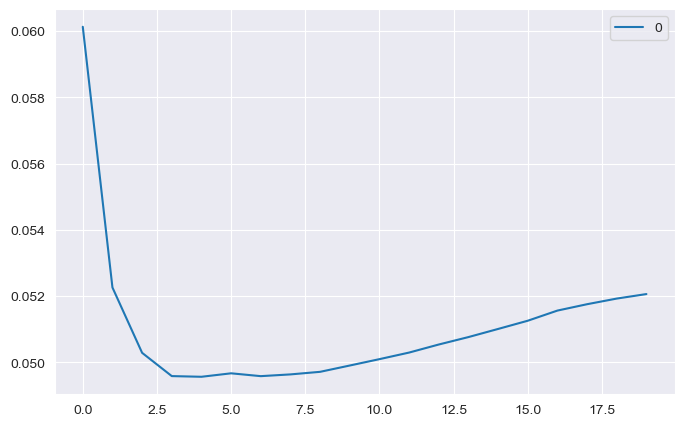

In [23]:
sns.set_style("darkgrid")
curve = pd.DataFrame(rmsle_val)
curve.plot(figsize=(8,5));
#plt.style.use("bmh")

In [24]:
knn = neighbors.KNeighborsRegressor(n_neighbors = best_k)

knn.fit(X_train,y_train)
y_pred_knn = knn.predict(X_test)


In [25]:
print("Puntaje test: ",knn.score(X_test, y_test))
print("Puntaje train: ",knn.score(X_train, y_train))


y_predTODOSKNN= knn.predict(X_final)
puntajetotal=knn.score(X_final,y)
print("Puntaje conjunto total: ", puntajetotal)

Puntaje test:  0.6014680051396778
Puntaje train:  0.7401009559515341
Puntaje conjunto total:  0.6984577565837655


In [26]:
# Ordenar los valores reales y mantener la relación con los predichos
sorted_indices_test = np.argsort(y_test)  # Obtener los índices ordenados de y_test
y_test_sorted = y_test[sorted_indices_test]  # Ordenar los valores reales
sorted_indices_pred = np.argsort(y_pred)
y_pred_sorted = y_pred[sorted_indices_pred]  # Reordenar las predicciones según esos índices

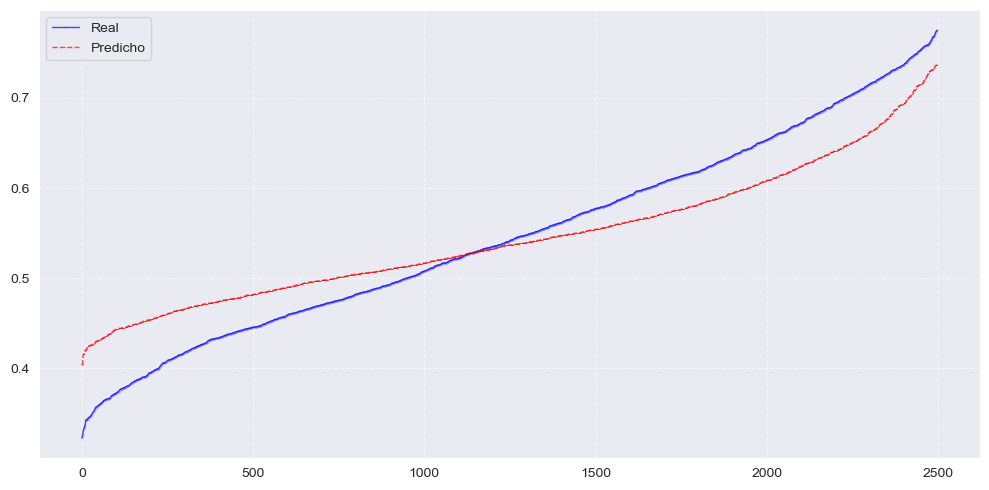

In [27]:

plt.figure(figsize=(10,5))

# Graficar datos reales y predichos
plt.plot(y_test_sorted[2:2500], label="Real", marker="o", linestyle="-", color="blue", markersize=0.1, linewidth=1, alpha=0.7)
plt.plot(y_pred_sorted[2:2500], label="Predicho", marker="x", linestyle="--", color="red", markersize=0.1, linewidth=1, alpha=0.7)

plt.legend(["Real", "Predicho"])  
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [28]:
y_test_unscaled = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_unscaled = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()
y_test_original = np.exp(y_test_unscaled)
y_pred_original = np.exp(y_pred_unscaled)

residuos = y_test_unscaled  - y_pred_unscaled  # Diferencia entre valores logaritmicos reales y predichos
residuosreales = y_test_original - y_pred_original


## Regresiones

In [29]:
# Estandarizar datos
scaler_XRidge = MinMaxScaler()
scaler_yRidge = MinMaxScaler()
#df_numerico.drop(["Fault Plane (1; 2; X)"], axis=1, inplace=True) #Se va a codificar dsp.
# Escalar las variables predictoras
df_scaledRidge = pd.DataFrame(scaler_XRidge.fit_transform(df_numerico.drop("T_0.01_RotD50", axis=1)), 
                         columns=df_numerico.drop("T_0.01_RotD50", axis=1).columns)
# Escalar la variable de respuesta
Aceleracion_escalada = scaler_yRidge.fit_transform(df_numerico[["T_0.01_RotD50"]])  # Debe ser 2D
df_scaledRidge["T_0.01_RotD50"] = Aceleracion_escalada.flatten()

In [30]:
df_scaledRidge

,Hypocenter Depth (km),Magnitude,Nodal Plane 1 Strike (deg),Nodal Plane 1 Dip (deg),Nodal Plane 1 Rake Angle (deg),Nodal Plane 2 Strike (deg),Nodal Plane 2 Dip (deg),Nodal Plane 2 Rake Angle (deg),Station Elevation (m),Repi_OpenQuake,Rjb_OpenQuake,Rrup_OpenQuake,Rx_OpenQuake,Rhypo_OpenQuake,Ry0_OpenQuake,T_0.01_RotD50
0,0.095740,1.000000,0.069832,0.224719,0.844444,0.475000,0.776316,0.722689,0.643756,0.105786,0.085457,0.082760,0.554825,0.101188,0.016449,0.818684
1,0.071805,0.728266,0.072626,0.191011,0.841667,0.483333,0.802632,0.728291,0.643756,0.119195,0.112994,0.107552,0.552428,0.113096,0.049363,0.719777
2,0.138822,0.770529,0.072626,0.224719,0.841667,0.483333,0.776316,0.722689,0.643756,0.116516,0.107878,0.103840,0.548503,0.111659,0.056134,0.746389
3,0.095740,1.000000,0.069832,0.224719,0.844444,0.475000,0.776316,0.722689,0.002178,0.212135,0.176793,0.172278,0.546718,0.207081,0.170115,0.808264
4,0.071805,0.728266,0.072626,0.191011,0.841667,0.483333,0.802632,0.728291,0.002178,0.223804,0.214401,0.209067,0.545724,0.218117,0.203278,0.678944
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8804,0.071805,0.150670,0.391061,0.921348,0.588889,0.133333,0.578947,0.985994,0.167473,0.162659,0.163924,0.158279,0.481339,0.156503,0.170411,0.626334
8805,0.713260,0.200894,0.025140,1.000000,0.416667,0.280556,0.605263,0.000000,0.167473,0.097938,0.098658,0.122335,0.525158,0.121965,0.079351,0.597561
8806,0.090953,0.226006,0.117318,0.269663,0.255556,0.616667,0.671053,0.249300,0.167473,0.482159,0.483458,0.479653,0.387227,0.478326,0.464461,0.390752
8807,0.014361,0.326453,0.782123,0.752809,0.558333,0.511111,0.750000,0.943978,0.167473,0.397385,0.398389,0.394397,0.474269,0.392762,0.415500,0.485474


In [31]:
X_numericalRidge = df_scaledRidge.drop(columns=["T_0.01_RotD50"]).values
yRidge = df_scaledRidge["T_0.01_RotD50"].values

In [32]:
# Paso 3: Combinar características numéricas y codificadas
X_finalRidge = np.hstack((X_numericalRidge, X_encoded,Y_encoded,Z_encoded))

In [33]:
X_trainRidge, X_testRidge, y_trainRidge, y_testRidge = train_test_split(X_finalRidge, yRidge, test_size=0.3, random_state=0)

### Regresión Lineal estándar

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [35]:
lr = LinearRegression().fit(X_trainRidge, y_trainRidge)

In [36]:
y_pred_reglineal = lr.predict(X_testRidge)
y_predTODOSREGLINEAL= lr.predict(X_finalRidge)

In [37]:
print("lr.coef_: {}".format(lr.coef_))
print("lr.intercept_: {}".format(lr.intercept_))

lr.coef_: [-8.17691453e-02  2.13173745e-01  8.47187070e-05 -7.51274641e-03
 -2.00824451e-03 -1.08309326e-02 -4.80337703e-03 -1.40831037e-02
  5.45396337e-04  4.84629109e+00 -6.96447376e+00  1.05564342e+00
 -2.34608551e-02  7.31801831e-01  4.80396240e-03  8.48216491e-04
  3.48668489e-02  3.22232944e-03 -3.89373948e-02  6.52590866e-04
 -6.52590866e-04 -6.77987179e-03 -2.90242720e-04  7.07011451e-03]
lr.intercept_: 0.6351508283592688


In [38]:
print("Training set score: {:.2f}".format(lr.score(X_trainRidge, y_trainRidge)))
print("Test set score: {:.2f}".format(lr.score(X_testRidge, y_testRidge)))

Training set score: 0.54
Test set score: 0.51


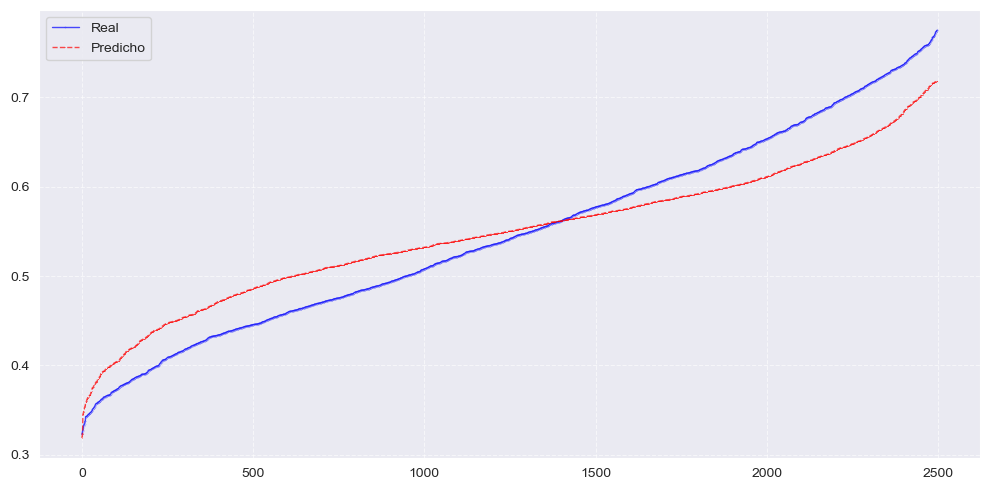

In [39]:
sorted_indices_pred = np.argsort(y_pred_reglineal)
y_pred_sorted_reglineal = y_pred_reglineal[sorted_indices_pred]  # Reordenar las predicciones según esos índices
plt.figure(figsize=(10,5))

# Graficar datos reales y predichos
plt.plot(y_test_sorted[2:2500], label="Real", marker="o", linestyle="-", color="blue", markersize=0.1, linewidth=1, alpha=0.7)
plt.plot(y_pred_sorted_reglineal[2:2500], label="Predicho", marker="x", linestyle="--", color="red", markersize=0.1, linewidth=1, alpha=0.7)

plt.legend(["Real", "Predicho"])  
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Regresión Ridge

In [40]:
from sklearn.linear_model import Ridge

In [41]:
ridge = Ridge(alpha=10).fit(X_trainRidge, y_trainRidge)
print("Training set score: {:.2f}".format(ridge.score(X_trainRidge, y_trainRidge)))
print("Test set score: {:.2f}".format(ridge.score(X_testRidge, y_testRidge)))

Training set score: 0.51
Test set score: 0.48


In [42]:
y_pred_Ridge = ridge.predict(X_testRidge)
y_predTODOSRIDGE = ridge.predict(X_finalRidge)

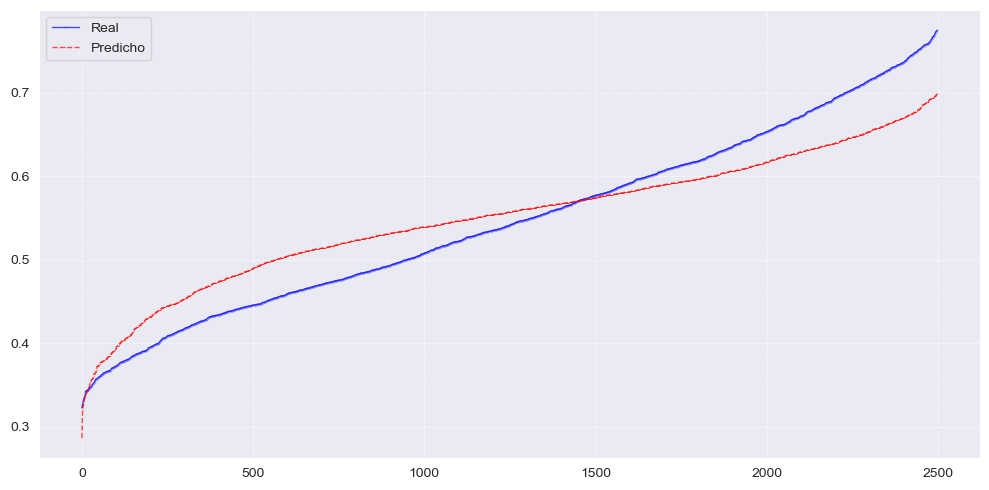

In [43]:
sorted_indices_predRidge = np.argsort(y_pred_Ridge)
y_pred_sorted_Ridge = y_pred_Ridge[sorted_indices_predRidge]  # Reordenar las predicciones según esos índices
plt.figure(figsize=(10,5))

# Graficar datos reales y predichos
plt.plot(y_test_sorted[2:2500], label="Real", marker="o", linestyle="-", color="blue", markersize=0.1, linewidth=1, alpha=0.7)
plt.plot(y_pred_sorted_Ridge[2:2500], label="Predicho", marker="x", linestyle="--", color="red", markersize=0.1, linewidth=1, alpha=0.7)

plt.legend(["Real", "Predicho"])  
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Regresión Lasso

In [44]:
from sklearn.linear_model import Lasso
lasso = Lasso().fit(X_trainRidge, y_trainRidge)
print("Training set score: {:.2f}".format(lasso.score(X_trainRidge, y_trainRidge)))
print("Test set score: {:.2f}".format(lasso.score(X_testRidge, y_testRidge)))
print("Number of features used: {}".format(np.sum(lasso.coef_ != 0)))

Training set score: 0.00
Test set score: -0.00
Number of features used: 0


In [45]:
lasso0001 = Lasso(alpha=0.0001, max_iter=10000000).fit(X_trainRidge, y_trainRidge)
print("Training set score: {:.2f}".format(lasso0001.score(X_trainRidge, y_trainRidge)))
print("Test set score: {:.2f}".format(lasso0001.score(X_testRidge, y_testRidge)))
print("Number of features used: {}".format(np.sum(lasso0001.coef_ != 0)))

Training set score: 0.52
Test set score: 0.48
Number of features used: 16


In [46]:
y_pred_Lasso= lasso0001.predict(X_testRidge)
y_predTODOSLASSO= lasso0001.predict(X_finalRidge)

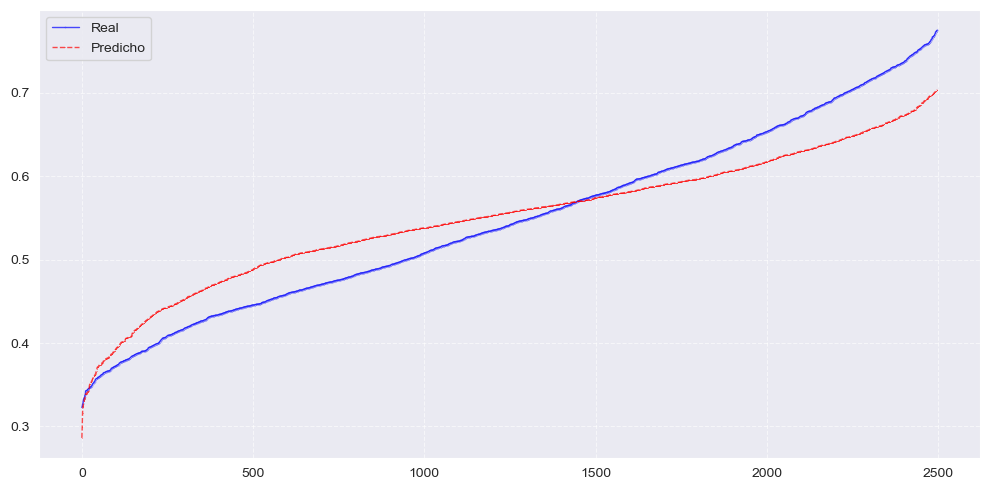

In [47]:
sorted_indices_predLasso = np.argsort(y_pred_Lasso)
y_pred_sorted_Lasso = y_pred_Lasso[sorted_indices_predLasso]  # Reordenar las predicciones según esos índices
plt.figure(figsize=(10,5))

# Graficar datos reales y predichos
plt.plot(y_test_sorted[2:2500], label="Real", marker="o", linestyle="-", color="blue", markersize=0.1, linewidth=1, alpha=0.7)
plt.plot(y_pred_sorted_Lasso[2:2500], label="Predicho", marker="x", linestyle="--", color="red", markersize=0.1, linewidth=1, alpha=0.7)

plt.legend(["Real", "Predicho"])  
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Árboles de decisión

### Random Forest

In [48]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression

In [49]:
X_trainRAND, X_testRAND, y_trainRAND, y_testRAND = train_test_split(X_finalRidge, yRidge, test_size=0.3, random_state=0)


In [50]:
from sklearn.model_selection import learning_curve

In [51]:
randforreg = RandomForestRegressor(n_estimators=100, criterion='squared_error', max_depth=9, min_samples_split=2, min_samples_leaf=10,
                                   min_weight_fraction_leaf=0.0, max_features=1.0, max_leaf_nodes=None, min_impurity_decrease=0.0, bootstrap=True,
                                   oob_score=False, n_jobs=None, random_state=0, verbose=0, warm_start=False, ccp_alpha=0.0, max_samples=None,
                                   monotonic_cst=None)

In [52]:
"""from sklearn.model_selection import GridSearchCV

param_grid = {
    'min_samples_split': [2, 5, 10, 20],  # Valores más altos = menos splits
    'min_samples_leaf': [1, 2, 4, 8],  # Valores altos = más generalización
}

grid = GridSearchCV(randforreg, param_grid, scoring='r2', cv=3, n_jobs=7)
grid.fit(X_trainRAND, y_trainRAND)

print("Mejores parámetros:", grid.best_params_)"""

'from sklearn.model_selection import GridSearchCV\n\nparam_grid = {\n    \'min_samples_split\': [2, 5, 10, 20],  # Valores más altos = menos splits\n    \'min_samples_leaf\': [1, 2, 4, 8],  # Valores altos = más generalización\n}\n\ngrid = GridSearchCV(randforreg, param_grid, scoring=\'r2\', cv=3, n_jobs=7)\ngrid.fit(X_trainRAND, y_trainRAND)\n\nprint("Mejores parámetros:", grid.best_params_)'

In [53]:
randforreg.fit(X_trainRAND, y_trainRAND)

RandomForestRegressor(max_depth=9, min_samples_leaf=10, random_state=0)

In [54]:
y_predRAND = randforreg.predict(X_testRAND)
y_predTODOSRAND= randforreg.predict(X_finalRidge)

In [55]:
print("Training set score: {:.2f}".format(randforreg.score(X_trainRAND, y_trainRAND)))
print("Test set score: {:.2f}".format(randforreg.score(X_testRAND, y_testRAND)))
print("Total score: {:.2f}".format(randforreg.score(X_finalRidge, yRidge)))

Training set score: 0.80
Test set score: 0.76
Total score: 0.78


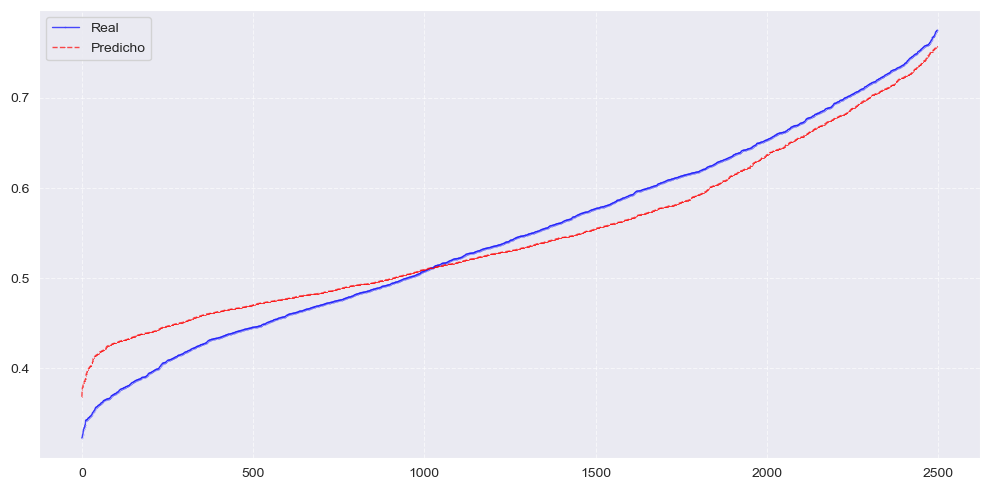

In [56]:
sorted_indices_predRAND= np.argsort(y_predRAND)
y_pred_sortedRAND = y_predRAND[sorted_indices_predRAND]  # Reordenar las predicciones según esos índices
plt.figure(figsize=(10,5))

# Graficar datos reales y predichos
plt.plot(y_test_sorted[2:2500], label="Real", marker="o", linestyle="-", color="blue", markersize=0.1, linewidth=1, alpha=0.7)
plt.plot(y_pred_sortedRAND[2:2500], label="Predicho", marker="x", linestyle="--", color="red", markersize=0.1, linewidth=1, alpha=0.7)

plt.legend(["Real", "Predicho"])  
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### XGBoost

In [57]:
import xgboost as xgb
from xgboost import XGBRegressor
print(xgb.build_info())
import lime
from lime.lime_tabular import LimeTabularExplainer



{'BUILTIN_PREFETCH_PRESENT': False, 'CUDA_VERSION': [12, 4], 'DEBUG': False, 'MM_PREFETCH_PRESENT': True, 'THRUST_VERSION': [2, 3, 2], 'USE_CUDA': True, 'USE_DLOPEN_NCCL': False, 'USE_FEDERATED': False, 'USE_NCCL': False, 'USE_OPENMP': True, 'USE_RMM': False, 'libxgboost': 'C:\\Users\\elias\\AppData\\Roaming\\Python\\Python39\\site-packages\\xgboost\\lib\\xgboost.dll'}


In [58]:
print(xgb.__version__)

2.1.4


In [59]:
X_XGB=df_scaled.copy()
X_XGB['Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)'] = df_copy['Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)']
X_XGB['Fault Plane (1; 2; X)'] = df_copy['Fault Plane (1; 2; X)']
X_XGB['Style-of-Faulting (S; R; N; U)'] = df_copy['Style-of-Faulting (S; R; N; U)']
"""X_XGB['Topografia'] = df_copy['Topografia']
X_XGB['Geologia'] = df_copy['Geologia']"""
X_XGB[categorical_columns] = X[categorical_columns].astype('category')

In [60]:
Y_XGB=X_XGB["T_0.01_RotD50"].copy()
X_XGB.drop(["T_0.01_RotD50"],axis=1, inplace=True)

In [61]:
XGBRegressor(tree_method='gpu_hist', gpu_id=1)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, gpu_id=1, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, ...)

In [62]:
X_trainXGB, X_testXGB, y_trainXGB, y_testXGB = train_test_split(X_XGB, Y_XGB, test_size=0.3, random_state=0)

# Modelo con GPU
modelXGB = XGBRegressor(tree_method="gpu_hist", gpu_id=1, enable_categorical=True, n_estimators=1000, max_depth=6, gamma=0,
                        reg_lambda = 0.01, reg_alpha= 1)
modelXGB.fit(X_trainXGB, y_trainXGB)

# Predicciones
y_predXGB = modelXGB.predict(X_testXGB)
y_predTODOSXGB= modelXGB.predict(X_XGB)
yTodosXGBArray = np.array(Y_XGB)

In [63]:
"""from sklearn.model_selection import GridSearchCV

param_gridXGB = {
    'gamma': [0, 0.001, 0.01, 0.1],
    'reg_lambda': [0.1,1,10,100],
    'reg_alpha' : [0.1,1,10,100],
    'max_depth' : [6,7,8,9]
}

grid = GridSearchCV(modelXGB, param_gridXGB, scoring='r2', cv=3, n_jobs=7)
grid.fit(X_trainXGB, y_trainXGB)

print("Mejores parámetros:", grid.best_params_)"""

'from sklearn.model_selection import GridSearchCV\n\nparam_gridXGB = {\n    \'gamma\': [0, 0.001, 0.01, 0.1],\n    \'reg_lambda\': [0.1,1,10,100],\n    \'reg_alpha\' : [0.1,1,10,100],\n    \'max_depth\' : [6,7,8,9]\n}\n\ngrid = GridSearchCV(modelXGB, param_gridXGB, scoring=\'r2\', cv=3, n_jobs=7)\ngrid.fit(X_trainXGB, y_trainXGB)\n\nprint("Mejores parámetros:", grid.best_params_)'

In [64]:
print("Train set : ",modelXGB.score(X_trainXGB, y_trainXGB))
print("Test set : ",modelXGB.score(X_testXGB, y_testXGB))

Train set :  0.874923405854231
Test set :  0.8287902636661468


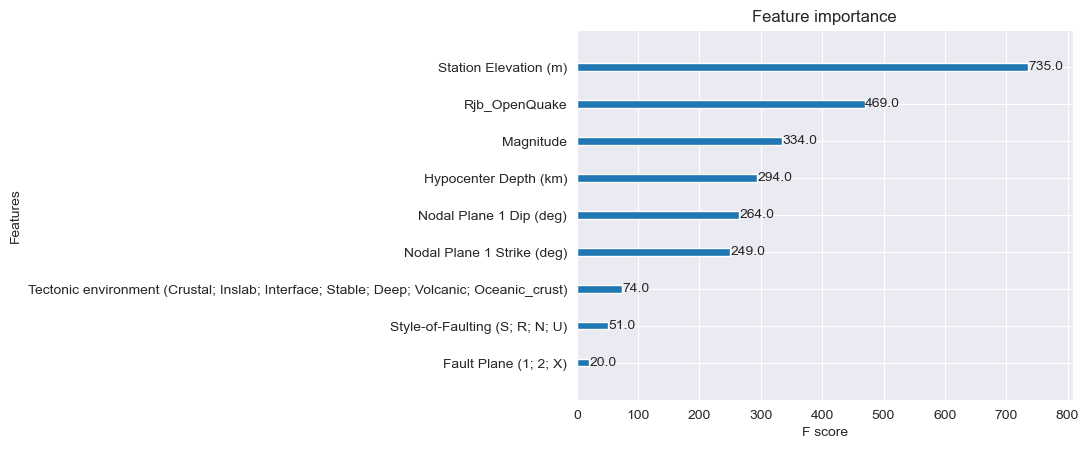

In [65]:
xgb.plot_importance(modelXGB)
plt.show()

#### PARA USAR LIME


In [66]:
categorical_columnsXGB = X_trainXGB.select_dtypes(include=['category']).columns
categorical_indexesXGB = [X_trainXGB.columns.get_loc(col) for col in categorical_columnsXGB]

In [67]:
categorical_namesXGB = {}
for col in X_trainXGB.select_dtypes(include='category').columns:
    idx = X_trainXGB.columns.get_loc(col)
    categorical_namesXGB[idx] = X_trainXGB[col].cat.categories.tolist()
    
cat_cols = ['Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)', 'Style-of-Faulting (S; R; N; U)'
            #,'Topografia','Geologia'
            ] 

for col in cat_cols:
    X_trainXGB[col] = X_trainXGB[col].astype('category')
    X_testXGB[col] = X_testXGB[col].astype('category')
X_trainXGB_lime = X_trainXGB.copy()
X_testXGB_lime = X_testXGB.copy()

for col in cat_cols:
    X_trainXGB_lime[col] = X_trainXGB_lime[col].cat.codes
    X_testXGB_lime[col] = X_testXGB_lime[col].cat.codes

categorical_indexesXGB = [X_trainXGB.columns.get_loc(col) for col in cat_cols]

categorical_namesXGB = {
    X_trainXGB.columns.get_loc(col): X_trainXGB[col].cat.categories.tolist()
    for col in cat_cols
}
explainer = LimeTabularExplainer(
    training_data=X_trainXGB_lime.values,
    feature_names=X_trainXGB.columns.tolist(),
    mode='regression',
    categorical_features=categorical_indexesXGB,
    categorical_names=categorical_namesXGB,
    discretize_continuous=False,
)


fila = 5
exp = explainer.explain_instance(
    data_row=X_testXGB_lime.iloc[fila].values,
    predict_fn=modelXGB.predict
)

exp.show_in_notebook(show_table=True, show_all=False)

In [68]:
print(X_trainXGB_lime.isna().sum())


Hypocenter Depth (km)                                                                       0
Magnitude                                                                                   0
Nodal Plane 1 Strike (deg)                                                                  0
Nodal Plane 1 Dip (deg)                                                                     0
Station Elevation (m)                                                                       0
Rjb_OpenQuake                                                                               0
Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)    0
Fault Plane (1; 2; X)                                                                       1
Style-of-Faulting (S; R; N; U)                                                              0
dtype: int64


In [112]:
X_trainXGB_lime[X_trainXGB_lime.isna().any(axis=1)]


,Hypocenter Depth (km),Magnitude,Nodal Plane 1 Strike (deg),Nodal Plane 1 Dip (deg),Station Elevation (m),Rjb_OpenQuake,Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust),Fault Plane (1; 2; X),Style-of-Faulting (S; R; N; U)
4079,0.031115,0.175782,0.748603,1.0,0.140852,0.308585,-1,NaN,-1


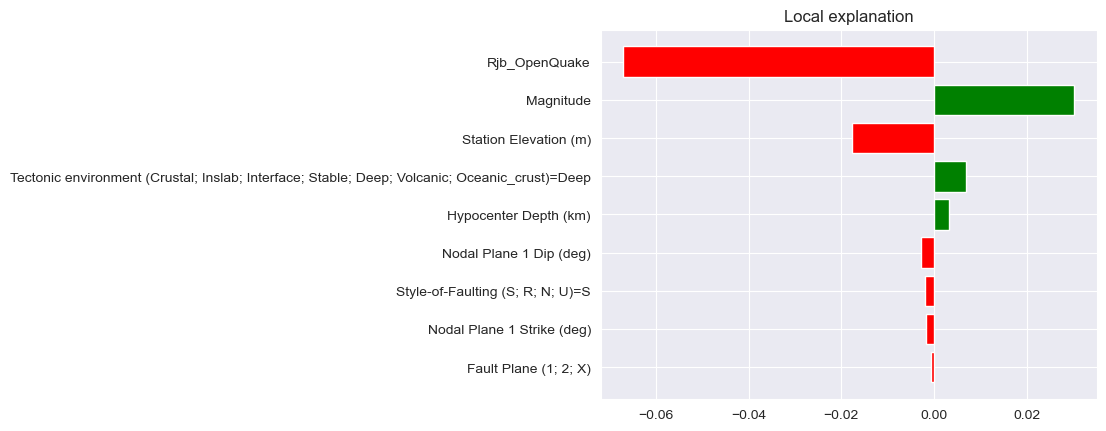

In [69]:
exp.as_pyplot_figure()
plt.show()

In [70]:

# Conversión directa con np.array()
y_test_array = np.array(y_testXGB)#['T_0.01_RotD50'])  # DataFrame -> Array
# Ordenar los valores reales y mantener la relación con los predichos
sorted_indices = np.argsort(y_test_array)  # Obtener los índices ordenados de y_test
y_test_sortedXGB = y_test_array[sorted_indices]  # Ordenar los valores reales
sorted_indices2 = np.argsort(y_predXGB) 
y_pred_sortedXGB = y_predXGB[sorted_indices2]  # Reordenar las predicciones según esos índices"""

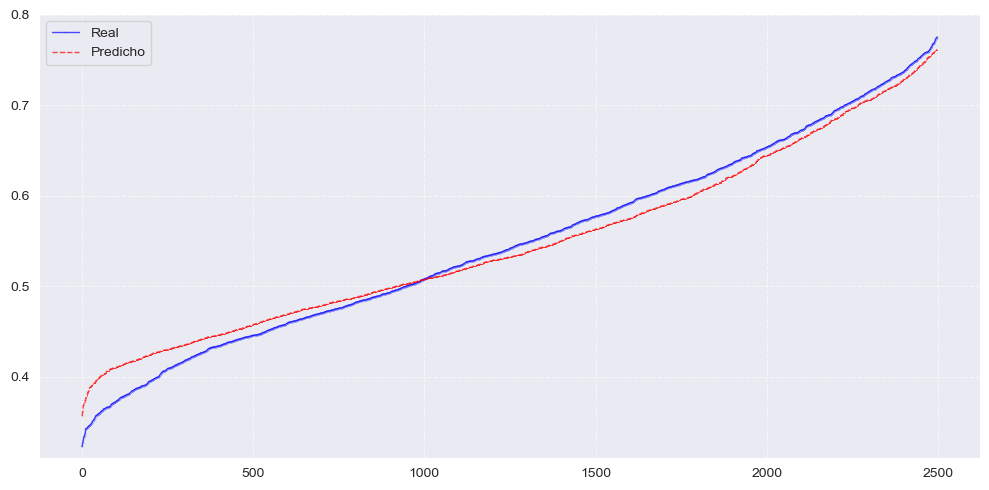

In [71]:

plt.figure(figsize=(10,5))

# Graficar datos reales y predichos
plt.plot(y_test_sortedXGB[2:2500], label="Real", marker="o", linestyle="-", color="blue", markersize=0.1, linewidth=1, alpha=0.7)
plt.plot(y_pred_sortedXGB[2:2500], label="Predicho", marker="x", linestyle="--", color="red", markersize=0.1, linewidth=1, alpha=0.7)

plt.legend(["Real", "Predicho"])  
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim([0.31,0.8])
plt.tight_layout()
plt.show()

## SVM

In [72]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error


In [73]:
"""from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.001, 0.01, 0.1, 1],
    'gamma': [0.001, 0.01, 0.1, 1, 'scale', 'auto'],
    'tol': [1e-4, 1e-3, 1e-2],
    'max_iter': [1000, 10000, -1]
}

grid_search = GridSearchCV(SVR(kernel='rbf'), param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=6)
grid_search.fit(X_train, y_train)

print("Mejor C:", grid_search.best_params_['C'])
print("Mejor epsilon:", grid_search.best_params_['epsilon'])
print("Mejor gamma:", grid_search.best_params_['gamma'])
print("Mejor tol:", grid_search.best_params_['tol'])
print("Mejor max_iter:", grid_search.best_params_['max_iter'])"""



'from sklearn.model_selection import GridSearchCV\n\nparam_grid = {\n    \'C\': [0.1, 1, 10, 100],\n    \'epsilon\': [0.001, 0.01, 0.1, 1],\n    \'gamma\': [0.001, 0.01, 0.1, 1, \'scale\', \'auto\'],\n    \'tol\': [1e-4, 1e-3, 1e-2],\n    \'max_iter\': [1000, 10000, -1]\n}\n\ngrid_search = GridSearchCV(SVR(kernel=\'rbf\'), param_grid, cv=3, scoring=\'neg_mean_squared_error\', n_jobs=6)\ngrid_search.fit(X_train, y_train)\n\nprint("Mejor C:", grid_search.best_params_[\'C\'])\nprint("Mejor epsilon:", grid_search.best_params_[\'epsilon\'])\nprint("Mejor gamma:", grid_search.best_params_[\'gamma\'])\nprint("Mejor tol:", grid_search.best_params_[\'tol\'])\nprint("Mejor max_iter:", grid_search.best_params_[\'max_iter\'])'

In [74]:
svr_lineal = SVR(kernel='linear', C=1, epsilon=0.1) 
svr_lineal.fit(X_train,y_train)


SVR(C=1, kernel='linear')

In [75]:
svr_poly = SVR(kernel='poly', C=1.0, epsilon=0.1) 
svr_poly.fit(X_train,y_train)

SVR(kernel='poly')

In [76]:
svr_rbf = SVR(kernel='rbf', C=10, epsilon=0.1,shrinking = True) 
svr_rbf.fit(X_train,y_train)

SVR(C=10)

In [77]:
y_pred_svm= svr_rbf.predict(X_test)
y_predTODOSSVM= svr_rbf.predict(X_final)

In [78]:
print("Puntaje entrenamiento para svm con kernel lineal:" ,svr_lineal.score(X_train, y_train))
print("Puntaje test para svm con kernel lineal:" ,svr_lineal.score(X_test, y_test))
print("Puntaje entrenamiento para svm con kernel poly:" ,svr_poly.score(X_train, y_train))
print("Puntaje test para svm con kernel poly:" ,svr_poly.score(X_test, y_test))
print("Puntaje entrenamiento para svm con kernel rbf:" ,svr_rbf.score(X_train, y_train))
print("Puntaje test para svm con kernel rbf:" ,svr_rbf.score(X_test, y_test))

Puntaje entrenamiento para svm con kernel lineal: 0.510560730205486
Puntaje test para svm con kernel lineal: 0.478375189139447
Puntaje entrenamiento para svm con kernel poly: 0.6549072778912766
Puntaje test para svm con kernel poly: 0.6335861617534384
Puntaje entrenamiento para svm con kernel rbf: 0.670116791716445
Puntaje test para svm con kernel rbf: 0.6455765302630097


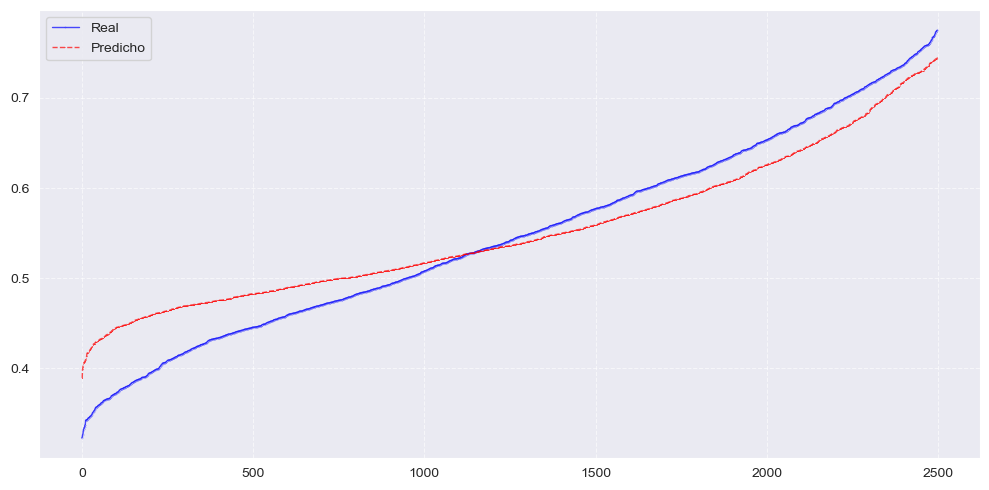

In [79]:
sorted_indices_predSVM= np.argsort(y_pred_svm)
y_pred_sortedSVM = y_pred_svm[sorted_indices_predSVM]  # Reordenar las predicciones según esos índices
plt.figure(figsize=(10,5))

# Graficar datos reales y predichos
plt.plot(y_test_sorted[2:2500], label="Real", marker="o", linestyle="-", color="blue", markersize=0.1, linewidth=1, alpha=0.7)
plt.plot(y_pred_sortedSVM[2:2500], label="Predicho", marker="x", linestyle="--", color="red", markersize=0.1, linewidth=1, alpha=0.7)

plt.legend(["Real", "Predicho"])  
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Tabla de métricas

In [80]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox


epsilon = 1e-6  # Pequeño valor para evitar divisiones por cero
#MAPE
mape_knn = mean_absolute_percentage_error(np.maximum(y_test, epsilon), y_pred_knn) * 100
mape_regl = mean_absolute_percentage_error(np.maximum(y_testRidge, epsilon), y_pred_reglineal) * 100
mape_ridge = mean_absolute_percentage_error(np.maximum(y_testRidge, epsilon), y_pred_Ridge) * 100
mape_lasso = mean_absolute_percentage_error(np.maximum(y_testRidge, epsilon), y_pred_Lasso) * 100
mape_rand = mean_absolute_percentage_error(np.maximum(y_test, epsilon), y_predRAND) * 100
mape_xgb = mean_absolute_percentage_error(np.maximum(y_testXGB, epsilon), y_predXGB) * 100
mape_svm = mean_absolute_percentage_error(np.maximum(y_test, epsilon), y_pred_svm) * 100


#RMSE
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))  # RMSE
rmse_regl = np.sqrt(mean_squared_error(y_testRidge, y_pred_reglineal))
rmse_ridge = np.sqrt(mean_squared_error(y_testRidge, y_pred_Ridge))
rmse_lasso = np.sqrt(mean_squared_error(y_testRidge, y_pred_Lasso))
rmse_rand = np.sqrt(mean_squared_error(y_test, y_predRAND))
rmse_xgb = np.sqrt(mean_squared_error(y_testXGB, y_predXGB))
rmse_svm = np.sqrt(mean_squared_error(y_test, y_pred_svm))


#R2

r2_knn = r2_score(y_test, y_pred_knn)  # R²
r2_regl = r2_score(y_testRidge, y_pred_reglineal)  # R²
r2_ridge = r2_score(y_testRidge, y_pred_Ridge)  # R²
r2_lasso = r2_score(y_testRidge, y_pred_Lasso)  # R²
r2_rand = r2_score(y_test, y_predRAND)  # R²
r2_xgb = r2_score(y_testXGB, y_predXGB)
r2_svm = r2_score(y_test, y_pred_svm)  # R²

# Calcular Ljung-Box (test de autocorrelación de residuos)
residuos_knn = y_test - y_pred_knn
ljung_box_knn = acorr_ljungbox(residuos_knn, lags=1, return_df=True)['lb_pvalue'].iloc[0]  # p-value
residuos_regl = y_testRidge - y_pred_reglineal
ljung_box_regl = acorr_ljungbox(residuos_regl, lags=1, return_df=True)['lb_pvalue'].iloc[0]  # p-value
residuos_ridge = y_testRidge - y_pred_Ridge
ljung_box_ridge = acorr_ljungbox(residuos_ridge, lags=1, return_df=True)['lb_pvalue'].iloc[0]  # p-value
residuos_lasso = y_testRidge - y_pred_Lasso
ljung_box_lasso = acorr_ljungbox(residuos_lasso, lags=1, return_df=True)['lb_pvalue'].iloc[0]  # p-value
residuos_rand = y_testRAND - y_predRAND
ljung_box_rand = acorr_ljungbox(residuos_rand, lags=1, return_df=True)['lb_pvalue'].iloc[0]  # p-value
residuos_xgb = y_testXGB - y_predXGB
ljung_box_xgb = acorr_ljungbox(residuos_xgb, lags=1, return_df=True)['lb_pvalue'].iloc[0]  # p-value
residuos_svm = y_test - y_pred_svm
ljung_box_svm = acorr_ljungbox(residuos_svm, lags=1, return_df=True)['lb_pvalue'].iloc[0]  # p-value

# Calcular Jarque-Bera (test de normalidad de residuos)
jb_test_knn = jarque_bera(residuos_knn)
jarque_bera_knn = jb_test_knn.pvalue  # p-value
jb_test_regl = jarque_bera(residuos_regl)
jarque_bera_regl = jb_test_regl.pvalue
jb_test_ridge = jarque_bera(residuos_ridge)
jarque_bera_ridge = jb_test_ridge.pvalue
jb_test_lasso = jarque_bera(residuos_lasso)
jarque_bera_lasso = jb_test_lasso.pvalue
jb_test_rand = jarque_bera(residuos_rand)
jarque_bera_rand = jb_test_rand.pvalue
jb_test_xgb = jarque_bera(residuos_xgb)
jarque_bera_xgb = jb_test_xgb.pvalue
jb_test_svm = jarque_bera(residuos_svm)
jarque_bera_svm = jb_test_svm.pvalue


tabla_resultados = pd.DataFrame({
    'Modelo': ['K-NN','Regresión Lineal','Regresión Ridge','Regresión Lasso','Random Forest','XGBoost','SVM'],
    'MAPE (%)': [mape_knn, mape_regl, mape_ridge, mape_lasso, mape_rand, mape_xgb, mape_svm],
    'RMSE': [rmse_knn, rmse_regl, rmse_ridge, rmse_lasso, rmse_rand, rmse_xgb, rmse_svm],
    'R²': [r2_knn, r2_regl, r2_ridge, r2_lasso, r2_rand, r2_xgb, r2_svm],
    'Ljung-Box p-value': [ljung_box_knn, ljung_box_regl, ljung_box_ridge, ljung_box_lasso, ljung_box_rand, ljung_box_xgb, ljung_box_svm],
    'Jarque-Bera p-value': [jarque_bera_knn, jarque_bera_regl, jarque_bera_ridge, jarque_bera_lasso, jarque_bera_rand, jarque_bera_xgb, jarque_bera_svm]
})



In [81]:
len(y_pred)

2643

In [82]:
tabla_resultados

,Modelo,MAPE (%),RMSE,R²,Ljung-Box p-value,Jarque-Bera p-value
0,K-NN,11.093470,0.077068,0.601468,0.392403,4.878403e-55
1,Regresión Lineal,12.752904,0.085704,0.507151,0.493502,4.456618e-20
2,Regresión Ridge,13.214423,0.088114,0.479038,0.579338,3.539701e-20
3,Regresión Lasso,13.162397,0.087920,0.481334,0.550357,1.542169e-21
4,Random Forest,8.911933,0.060276,0.756221,0.326033,1.853876e-26
5,XGBoost,7.172204,0.050514,0.828790,0.424366,5.890138e-197
6,SVM,10.858516,0.072678,0.645577,0.591098,4.631157e-39


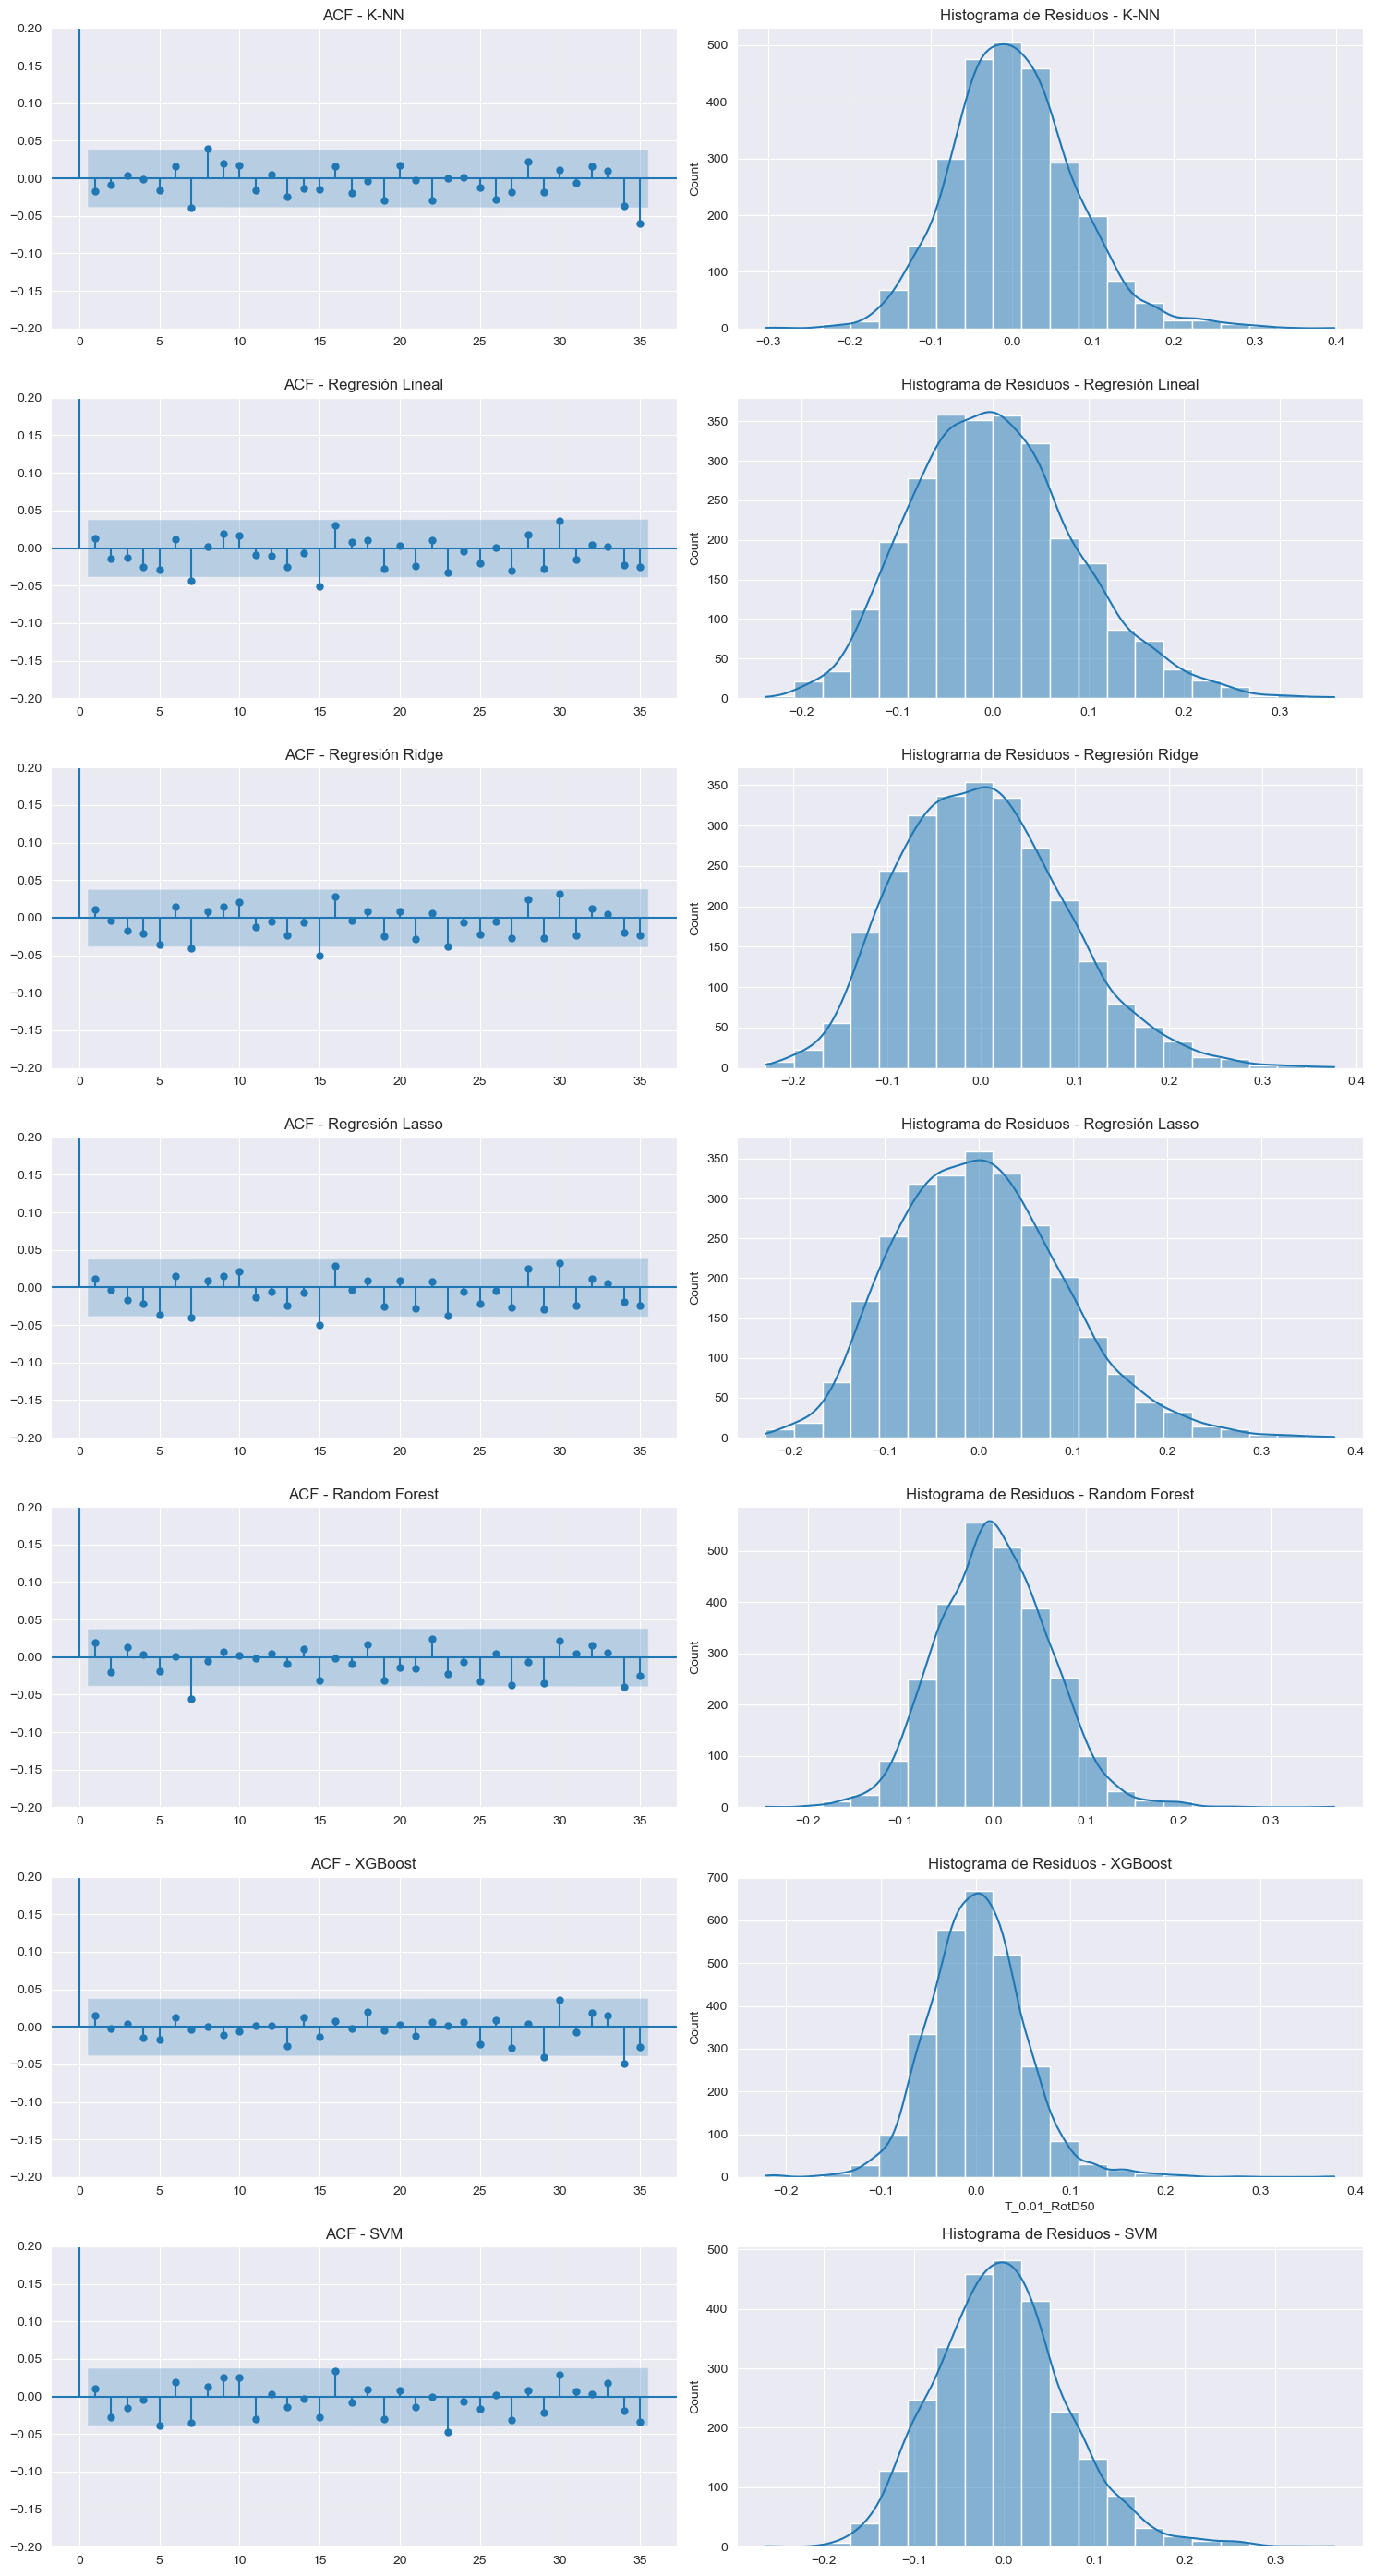

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf

modelos = {
    "K-NN": residuos_knn,
    "Regresión Lineal": residuos_regl,
    "Regresión Ridge": residuos_ridge,
    "Regresión Lasso": residuos_lasso,
    "Random Forest": residuos_rand,
    "XGBoost": residuos_xgb,
    "SVM": residuos_svm
}

fig, axes = plt.subplots(len(modelos), 2, figsize=(15, 4 * len(modelos)))

for i, (nombre, residuos) in enumerate(modelos.items()):
    # ACF de los residuos
    plot_acf(residuos, ax=axes[i, 0], title=f"ACF - {nombre}")
    axes[i,0].set_ylim(-0.2, 0.2)  # Límite en el eje y
    # Histograma de los residuos
    sns.histplot(residuos, bins=20, kde=True, ax=axes[i, 1])
    axes[i, 1].set_title(f"Histograma de Residuos - {nombre}")
    

plt.tight_layout()
plt.show()


In [84]:

residuos_knn_real_test = (scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten() - 
                    scaler_y.inverse_transform(y_pred_knn.reshape(-1, 1)).flatten())
                    
residuos_regl_real_test = (scaler_yRidge.inverse_transform(y_testRidge.reshape(-1, 1)).flatten() - 
                     scaler_yRidge.inverse_transform(y_pred_reglineal.reshape(-1, 1)).flatten())

residuos_ridge_real_test = (scaler_yRidge.inverse_transform(y_testRidge.reshape(-1, 1)).flatten() - 
                      scaler_yRidge.inverse_transform(y_pred_Ridge.reshape(-1, 1)).flatten())

residuos_lasso_real_test = (scaler_yRidge.inverse_transform(y_testRidge.reshape(-1, 1)).flatten() - 
                      scaler_yRidge.inverse_transform(y_pred_Lasso.reshape(-1, 1)).flatten())

residuos_rand_real_test = (scaler_y.inverse_transform(y_testRAND.reshape(-1, 1)).flatten() - 
                     scaler_y.inverse_transform(y_predRAND.reshape(-1, 1)).flatten())

residuos_xgb_real_test = (scaler_y.inverse_transform(y_test_array.reshape(-1, 1)).flatten() - 
                    scaler_y.inverse_transform(y_predXGB.reshape(-1, 1)).flatten())

residuos_svm_real_test = (scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten() - 
                    scaler_y.inverse_transform(y_pred_svm.reshape(-1, 1)).flatten())

residuos_reales_test = pd.DataFrame({
    'K-NN': residuos_knn_real_test,
    'Regresión Lineal': residuos_regl_real_test,
    'Regresión Ridge': residuos_ridge_real_test,
    'Regresión Lasso': residuos_lasso_real_test,
    'Random Forest': residuos_rand_real_test,
    'XGBoost': residuos_xgb_real_test,
    'SVM': residuos_svm_real_test
})

In [85]:
residuos_reales_test

,K-NN,Regresión Lineal,Regresión Ridge,Regresión Lasso,Random Forest,XGBoost,SVM
0,-0.328417,0.121812,0.147851,0.184726,0.348689,0.260985,0.108441
1,-0.346347,-0.979380,-0.965844,-1.019148,1.005345,0.352641,-0.115298
2,0.406214,-0.687065,-0.446110,-0.527423,-0.351093,-0.325751,0.349609
3,0.093013,-0.120187,-0.308440,-0.274413,0.257560,0.206896,0.314505
4,0.030360,-0.013930,0.097516,0.120636,-0.066057,0.096697,-1.055272
...,...,...,...,...,...,...,...
2638,-0.807625,-1.898859,-2.022673,-2.041060,-1.081026,-1.423247,-0.559587
2639,-0.411136,0.184309,-0.160218,-0.165275,0.110453,-0.494034,0.089903
2640,-0.979585,0.171123,0.317105,0.318874,-0.640031,-0.883718,-1.173587
2641,-0.280577,-0.836463,-0.830184,-0.839120,0.231756,0.549767,-0.240281


In [86]:
residuos_knn_real_total = (scaler_y.inverse_transform(y.reshape(-1, 1)).flatten() - 
                    scaler_y.inverse_transform(y_predTODOSKNN.reshape(-1, 1)).flatten())
                    
residuos_regl_real_total = (scaler_yRidge.inverse_transform(yRidge.reshape(-1, 1)).flatten() - 
                     scaler_yRidge.inverse_transform(y_predTODOSREGLINEAL.reshape(-1, 1)).flatten())

residuos_ridge_real_total = (scaler_yRidge.inverse_transform(yRidge.reshape(-1, 1)).flatten() - 
                      scaler_yRidge.inverse_transform(y_predTODOSRIDGE.reshape(-1, 1)).flatten())

residuos_lasso_real_total = (scaler_yRidge.inverse_transform(yRidge.reshape(-1, 1)).flatten() - 
                      scaler_yRidge.inverse_transform(y_predTODOSLASSO.reshape(-1, 1)).flatten())

residuos_rand_real_total = (scaler_y.inverse_transform(yRidge.reshape(-1, 1)).flatten() - 
                     scaler_y.inverse_transform(y_predTODOSRAND.reshape(-1, 1)).flatten())

residuos_xgb_real_total = (scaler_y.inverse_transform(yTodosXGBArray.reshape(-1, 1)).flatten() - 
                    scaler_y.inverse_transform(y_predTODOSXGB.reshape(-1, 1)).flatten())

residuos_svm_real_total = (scaler_y.inverse_transform(y.reshape(-1, 1)).flatten() - 
                    scaler_y.inverse_transform(y_predTODOSSVM.reshape(-1, 1)).flatten())

residuos_reales_total = pd.DataFrame({
    'K-NN': residuos_knn_real_total,
    'Regresión Lineal': residuos_regl_real_total,
    'Regresión Ridge': residuos_ridge_real_total,
    'Regresión Lasso': residuos_lasso_real_total,
    'Random Forest': residuos_rand_real_total,
    'XGBoost': residuos_xgb_real_total,
    'SVM': residuos_svm_real_total
})

In [87]:
residuos_reales_total

,K-NN,Regresión Lineal,Regresión Ridge,Regresión Lasso,Random Forest,XGBoost,SVM
0,0.112997,-0.519473,0.787858,0.589985,0.814538,0.569917,-0.358221
1,-0.771567,0.414386,0.406137,0.323634,-0.530352,-0.759746,-0.027880
2,0.104403,0.516417,0.663199,0.568775,-0.307008,-0.590811,-0.120389
3,-0.576403,-1.711563,1.302377,1.037400,1.326610,0.274040,-0.610420
4,-0.543427,-0.085399,0.372460,0.259851,-0.381655,-0.617664,-0.143406
...,...,...,...,...,...,...,...
8804,1.039725,1.262782,1.265848,1.246533,0.857841,0.965142,1.100144
8805,0.210823,-0.851201,-0.552642,-0.556222,-0.486306,-0.444327,-0.283667
8806,-0.014608,-0.805890,-0.746686,-0.720383,-1.482733,-1.070601,-1.340481
8807,-0.076023,-0.833046,-0.754083,-0.777847,-0.045807,-0.036558,-0.065805


In [88]:
residuos_reales_test.describe().T

,count,mean,std,min,25%,50%,75%,max
K-NN,2643.0,0.051810,1.474473,-5.807727,-0.908668,-0.028261,0.906504,7.610514
Regresión Lineal,2643.0,0.045967,1.640060,-4.558199,-1.106536,-0.041344,1.049742,6.843289
Regresión Ridge,2643.0,0.046419,1.686210,-4.399558,-1.183585,-0.034230,1.113607,7.210340
Regresión Lasso,2643.0,0.046907,1.682475,-4.327337,-1.157562,-0.048224,1.121430,7.226396
Random Forest,2643.0,0.020956,1.153719,-4.712171,-0.769878,-0.017198,0.770674,7.061127
XGBoost,2643.0,0.030896,0.966531,-4.243865,-0.583873,0.015474,0.599304,7.235486
SVM,2643.0,-0.052345,1.390358,-5.063048,-1.007889,-0.104485,0.777442,7.003892


In [90]:
residuos_reales_total.describe().T

,count,mean,std,min,25%,50%,75%,max
K-NN,8809.0,0.015834,1.280872,-11.254714,-0.776977,-0.027095,0.744711,7.610514
Regresión Lineal,8809.0,0.013792,1.601587,-12.493120,-1.110497,-0.071418,1.010534,7.446095
Regresión Ridge,8809.0,0.013927,1.644744,-12.852018,-1.163964,-0.058626,1.072439,7.258938
Regresión Lasso,8809.0,0.014074,1.640624,-12.910958,-1.156440,-0.057657,1.059711,7.350936
Random Forest,8809.0,0.005978,1.082984,-12.436369,-0.698249,-0.021078,0.649032,7.061127
XGBoost,8809.0,0.009273,0.869406,-11.355445,-0.519939,-0.027570,0.502559,7.235486
SVM,8809.0,-0.082546,1.351975,-13.292632,-1.013761,-0.147348,0.741835,7.621456


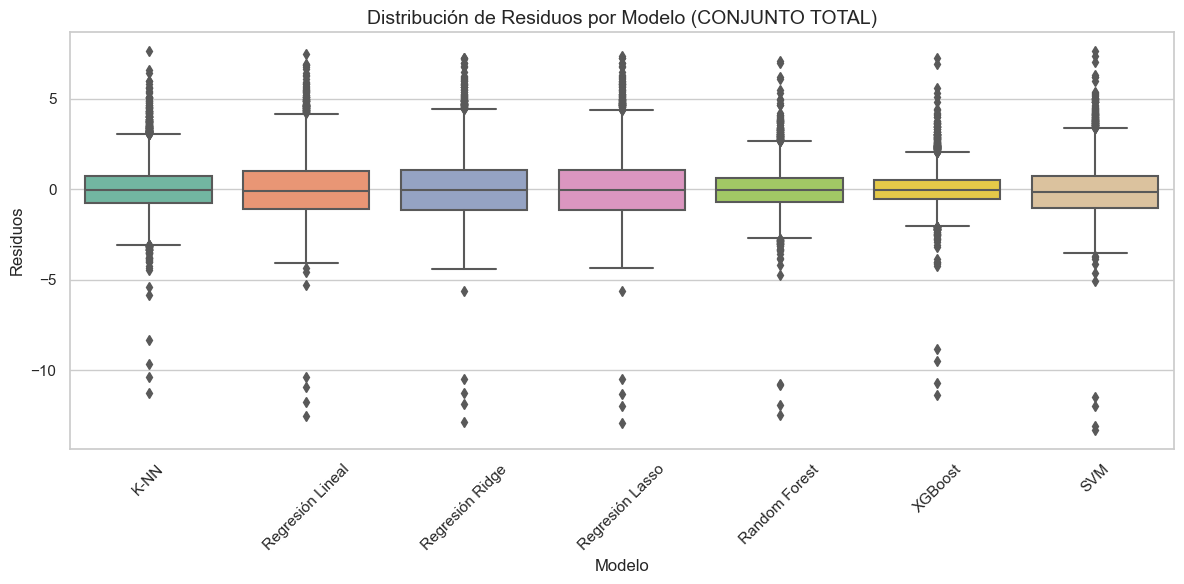

In [91]:

residuos_reales_largo = residuos_reales_total.melt(var_name='Modelo', value_name='Residuos')
sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))
sns.boxplot(x='Modelo', y='Residuos', data=residuos_reales_largo, palette="Set2")

plt.title('Distribución de Residuos por Modelo (CONJUNTO TOTAL)', fontsize=14)
plt.xlabel('Modelo')
plt.ylabel('Residuos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [92]:
np.exp(5)

148.4131591025766

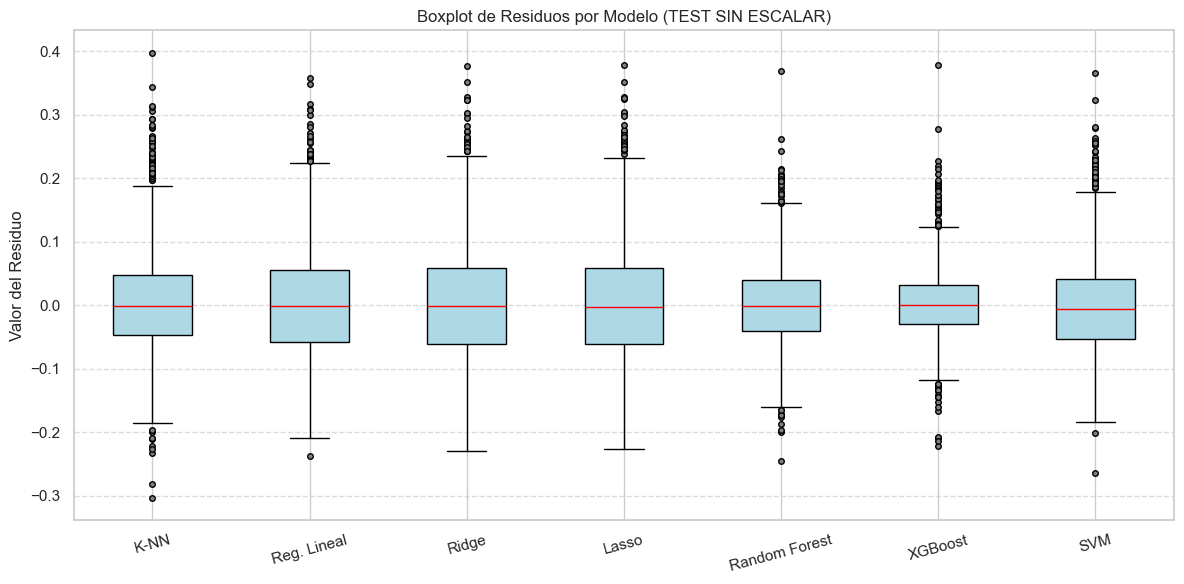

In [93]:
import matplotlib.pyplot as plt
residuos = [
    residuos_knn,
    residuos_regl,
    residuos_ridge,
    residuos_lasso,
    residuos_rand,
    residuos_xgb,
    residuos_svm
]
modelos = ['K-NN', 'Reg. Lineal', 'Ridge', 'Lasso', 'Random Forest', 'XGBoost', 'SVM']

plt.figure(figsize=(12, 6))
plt.boxplot(residuos, labels=modelos, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='black'),
            medianprops=dict(color='red'),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            flierprops=dict(marker='o', markerfacecolor='gray', markersize=4, linestyle='none'))

plt.title('Boxplot de Residuos por Modelo (TEST SIN ESCALAR)')
plt.ylabel('Valor del Residuo')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


#### Meta

In [94]:
from sklearn.ensemble import StackingRegressor
"""from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import BayesianRidge
from sklearn.linear_model import HuberRegressor, RANSACRegressor
from sklearn.ensemble import VotingRegressor  # Alternativa al stacking"""

'from sklearn.ensemble import GradientBoostingRegressor\nfrom sklearn.neural_network import MLPRegressor\nfrom sklearn.linear_model import BayesianRidge\nfrom sklearn.linear_model import HuberRegressor, RANSACRegressor\nfrom sklearn.ensemble import VotingRegressor  # Alternativa al stacking'

In [95]:

from sklearn.svm import SVR                       # Para SVM con kernel radial
"""from sklearn.neighbors import KNeighborsRegressor # Para KNN
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, StackingRegressor
from sklearn.linear_model import Ridge           # Para el meta-modelo de regresión
import lightgbm as lgb                          # Para LightGBM
from catboost import CatBoostRegressor          # Para CatBoost"""

'from sklearn.neighbors import KNeighborsRegressor # Para KNN\nfrom sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, StackingRegressor\nfrom sklearn.linear_model import Ridge           # Para el meta-modelo de regresión\nimport lightgbm as lgb                          # Para LightGBM\nfrom catboost import CatBoostRegressor          # Para CatBoost'

In [96]:
# Meta-modelo (puede ser una regresión lineal, Ridge, etc.)
meta_model = LinearRegression()
# Lista de modelos base (tuplas con nombre y objeto)
estimators = [
    ('xgb', modelXGB),                     # XGBoost (modelos de árboles de boosting)
    ('svm', svr_rbf),                      # SVM con kernel radial (modelo no lineal)
    #('knn', knn),                          # KNN (modelo basado en vecinos)
    #('reg',LinearRegression()),
    ('rf', randforreg)                      # Random Forest (modelo basado en árboles)
    #('gb', GradientBoostingRegressor()),   # Gradient Boosting (modelos de árboles)
    #('et', ExtraTreesRegressor()),         # Extra Trees (modelos de árboles)
    #('lgbm', lgb.LGBMRegressor()),         # LightGBM (modelo basado en boosting)
    #('catboost', CatBoostRegressor(loss_function='LogCosh'))     
]

In [97]:
stack = StackingRegressor(
    estimators=[],  # por defecto, pero se cambiará con el grid
    final_estimator=meta_model,
    passthrough=True,
    n_jobs=-1
)

In [98]:
"""param_grid = {
    'estimators': [
        [('xgb', modelXGB), ('svm', svr_rbf), ('knn', knn)],
        [('xgb', modelXGB), ('rf', randforreg), ('knn', knn)],
        [('xgb', modelXGB), ('svm', svr_rbf), ('reg', LinearRegression())],
        [('svm', svr_rbf), ('knn', knn), ('reg', LinearRegression())],
        [('xgb', modelXGB), ('rf', randforreg), ('reg', LinearRegression())],
        [('svm', svr_rbf), ('rf', randforreg), ('reg', LinearRegression())],
        [('xgb', modelXGB), ('rf', randforreg)],
        [('xgb', modelXGB), ('reg', LinearRegression())],
        [('svm', svr_rbf), ('reg', LinearRegression())]
    ],
    'final_estimator__alpha': [0.01, 0.1, 1.0, 10.0]
}
grid = GridSearchCV(
    estimator=stack,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best R²:", grid.best_score_)"""

'param_grid = {\n    \'estimators\': [\n        [(\'xgb\', modelXGB), (\'svm\', svr_rbf), (\'knn\', knn)],\n        [(\'xgb\', modelXGB), (\'rf\', randforreg), (\'knn\', knn)],\n        [(\'xgb\', modelXGB), (\'svm\', svr_rbf), (\'reg\', LinearRegression())],\n        [(\'svm\', svr_rbf), (\'knn\', knn), (\'reg\', LinearRegression())],\n        [(\'xgb\', modelXGB), (\'rf\', randforreg), (\'reg\', LinearRegression())],\n        [(\'svm\', svr_rbf), (\'rf\', randforreg), (\'reg\', LinearRegression())],\n        [(\'xgb\', modelXGB), (\'rf\', randforreg)],\n        [(\'xgb\', modelXGB), (\'reg\', LinearRegression())],\n        [(\'svm\', svr_rbf), (\'reg\', LinearRegression())]\n    ],\n    \'final_estimator__alpha\': [0.01, 0.1, 1.0, 10.0]\n}\ngrid = GridSearchCV(\n    estimator=stack,\n    param_grid=param_grid,\n    cv=3,\n    scoring=\'r2\',\n    verbose=1,\n    n_jobs=-1\n)\n\ngrid.fit(X_train, y_train)\n\nprint("Best params:", grid.best_params_)\nprint("Best R²:", grid.best_score_)

In [99]:
"""modelC = CatBoostRegressor(

    loss_function='LogCosh',     # Función de pérdida (en este caso, RMSE)
)

# Entrenar el modelo
modelC.fit(X_train, y_train,verbose=500)


# Evaluar el rendimiento
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
r2_catboosttest = modelC.score(X_test, y_test)
print(f'Test con CatBoost: {r2_catboosttest}')
r2_catboosttrain = modelC.score(X_train, y_train)
print(f'Train con CatBoost: {r2_catboosttrain}')"""

"modelC = CatBoostRegressor(\n\n    loss_function='LogCosh',     # Función de pérdida (en este caso, RMSE)\n)\n\n# Entrenar el modelo\nmodelC.fit(X_train, y_train,verbose=500)\n\n\n# Evaluar el rendimiento\nmse = mean_squared_error(y_test, y_pred)\nprint(f'Mean Squared Error: {mse}')\nr2_catboosttest = modelC.score(X_test, y_test)\nprint(f'Test con CatBoost: {r2_catboosttest}')\nr2_catboosttrain = modelC.score(X_train, y_train)\nprint(f'Train con CatBoost: {r2_catboosttrain}')"

In [100]:
"""lgb_model = lgb.LGBMRegressor()

# Entrenar
lgb_model.fit(X_train, y_train)

# Predecir
y_predlgb = lgb_model.predict(X_test)
y_predtrainlgb = lgb_model.predict(X_train)

# Evaluar

print(f'test R²: ', r2_score(y_test, y_predlgb))
print(f'train R²: ', r2_score(y_train, y_predtrainlgb))"""

"lgb_model = lgb.LGBMRegressor()\n\n# Entrenar\nlgb_model.fit(X_train, y_train)\n\n# Predecir\ny_predlgb = lgb_model.predict(X_test)\ny_predtrainlgb = lgb_model.predict(X_train)\n\n# Evaluar\n\nprint(f'test R²: ', r2_score(y_test, y_predlgb))\nprint(f'train R²: ', r2_score(y_train, y_predtrainlgb))"

In [101]:
stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=meta_model,
    cv=3,  # Validación cruzada para entrenar el meta-modelo
    n_jobs=-1,  # Paralelizar si es posible
    passthrough= False
)

In [102]:
stacking_model.fit(X_train, y_train)

StackingRegressor(cv=3,
                  estimators=[('xgb',
                               XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=True,
                                            eval_metric=None,
                                            feature_types=None, gamma=0,
                                            gpu_id=1, grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            l...
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=6,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=1000, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                              ('svm', SVR(C=10)),
                              ('rf',
                               RandomForestRegressor(max_depth=9,
                                                     min_samples_leaf=10,
                                                     random_state=0))],
                  final_estimator=LinearRegression(), n_jobs=-1)

In [103]:
y_train_pred_stacking = stacking_model.predict(X_train)
y_test_pred_stacking = stacking_model.predict(X_test)

In [104]:
print("Train R²:", r2_score(y_train, y_train_pred_stacking))
print("Test R²:", r2_score(y_test, y_test_pred_stacking))

Train R²: 0.8753602352710166
Test R²: 0.8317690588038301


In [105]:
print("Pesos del meta-modelo:", stacking_model.final_estimator_.coef_)

Pesos del meta-modelo: [ 1.1045888  -0.06429296 -0.02984429]


In [106]:

#MAPE
mape_stacking = mean_absolute_percentage_error(np.maximum(y_test, epsilon), y_test_pred_stacking) * 100
#RMSE
rmse_stacking = np.sqrt(mean_squared_error(y_test, y_test_pred_stacking))  # RMSE
#R2
r2_stacking = r2_score(y_test, y_test_pred_stacking)  # R²
# Calcular Ljung-Box (test de autocorrelación de residuos)
residuos_stacking = y_test - y_test_pred_stacking
ljung_box_stacking = acorr_ljungbox(residuos_stacking, lags=1, return_df=True)['lb_pvalue'].iloc[0]  # p-value
# Calcular Jarque-Bera (test de normalidad de residuos)
jb_test_stacking = jarque_bera(residuos_stacking)
jarque_bera_stacking = jb_test_stacking.pvalue  # p-value

In [107]:
tabla_resultados2 = pd.DataFrame({
    'Modelo': ['K-NN','Regresión Lineal','Regresión Ridge','Regresión Lasso','Random Forest','XGBoost','SVM', 'Stacking'],
    'MAPE (%)': [mape_knn, mape_regl, mape_ridge, mape_lasso, mape_rand, mape_xgb, mape_svm, mape_stacking],
    'RMSE': [rmse_knn, rmse_regl, rmse_ridge, rmse_lasso, rmse_rand, rmse_xgb, rmse_svm,rmse_stacking],
    'R²': [r2_knn, r2_regl, r2_ridge, r2_lasso, r2_rand, r2_xgb, r2_svm,r2_stacking],
    'Ljung-Box p-value': [ljung_box_knn, ljung_box_regl, ljung_box_ridge, ljung_box_lasso, ljung_box_rand, ljung_box_xgb, ljung_box_svm, ljung_box_stacking],
    'Jarque-Bera p-value': [jarque_bera_knn, jarque_bera_regl, jarque_bera_ridge, jarque_bera_lasso, jarque_bera_rand, jarque_bera_xgb, jarque_bera_svm,jarque_bera_stacking]
})

In [108]:
tabla_resultados2

,Modelo,MAPE (%),RMSE,R²,Ljung-Box p-value,Jarque-Bera p-value
0,K-NN,11.093470,0.077068,0.601468,0.392403,4.878403e-55
1,Regresión Lineal,12.752904,0.085704,0.507151,0.493502,4.456618e-20
2,Regresión Ridge,13.214423,0.088114,0.479038,0.579338,3.539701e-20
3,Regresión Lasso,13.162397,0.087920,0.481334,0.550357,1.542169e-21
4,Random Forest,8.911933,0.060276,0.756221,0.326033,1.853876e-26
5,XGBoost,7.172204,0.050514,0.828790,0.424366,5.890138e-197
6,SVM,10.858516,0.072678,0.645577,0.591098,4.631157e-39
7,Stacking,7.069070,0.050072,0.831769,0.507155,1.214313e-205


In [109]:
sorted_indices3 = np.argsort(y_test_pred_stacking) 
sorted_indices2 = np.argsort(y_predXGB) 
y_pred_sortedStack = y_test_pred_stacking[sorted_indices3]  # Reordenar las predicciones según esos índices

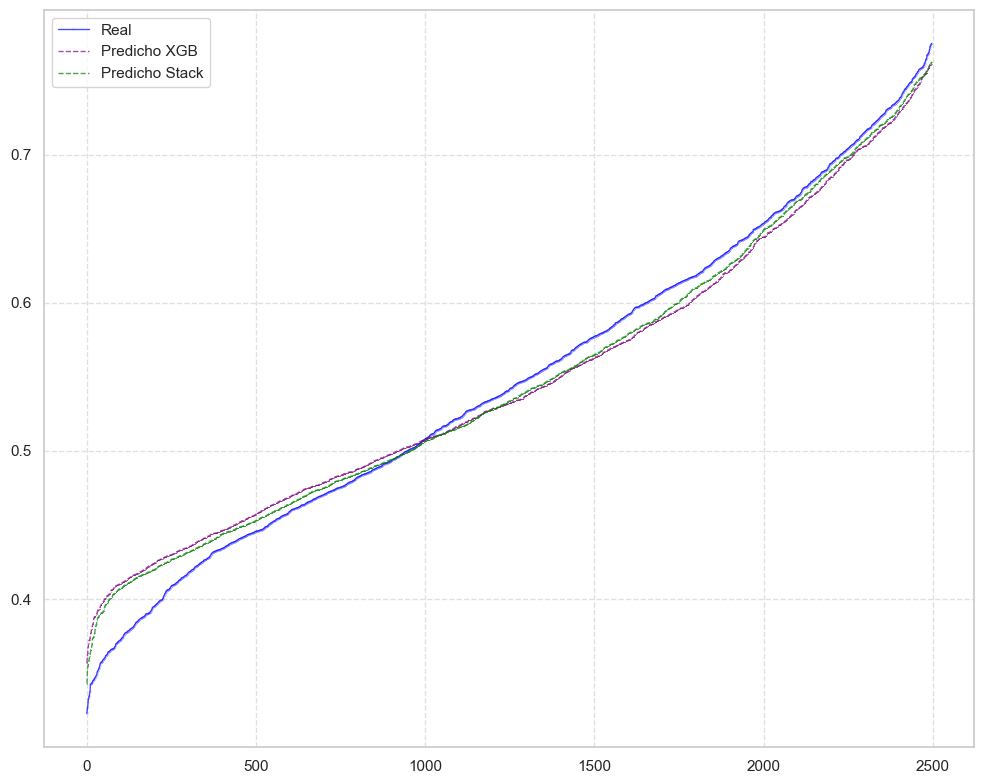

In [110]:
#plt.style.use('dark_background')
plt.figure(figsize=(10,8), )

# Graficar datos reales y predichos
plt.plot(y_test_sorted[2:2500], label="Real", marker="o", linestyle="-", color="blue", markersize=0.1, linewidth=1, alpha=0.7)
"""plt.plot(y_pred_sortedSVM[2:2500], label="Predicho SVM", marker="x", linestyle="--", color="red", markersize=0.1, linewidth=1, alpha=0.7)
plt.plot(y_pred_sorted[2:2500], label="Predicho KNN", marker="x", linestyle="--", color="pink", markersize=0.1, linewidth=1, alpha=0.7)
plt.plot(y_pred_sorted_Lasso[2:2500], label="Predicho Lasso", marker="x", linestyle="--", color="yellow", markersize=0.1, linewidth=1, alpha=0.7)
plt.plot(y_pred_sorted_reglineal[2:2500], label="Predicho Lineal", marker="x", linestyle="--", color="orange", markersize=0.1, linewidth=1, alpha=0.7)
plt.plot(y_pred_sortedRAND[2:2500], label="Predicho Random", marker="x", linestyle="--", color="white", markersize=0.1, linewidth=1, alpha=0.7)"""
plt.plot(y_pred_sortedXGB[2:2500], label="Predicho XGB", marker="x", linestyle="--", color="purple", markersize=0.1, linewidth=1, alpha=0.7)
plt.plot(y_pred_sortedStack[2:2500], label="Predicho Stack", marker="x", linestyle="--", color="green", markersize=0.1, linewidth=1, alpha=0.7)
plt.legend(["Real","Predicho XGB","Predicho Stack"])  
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()